# 0. Marking.

**_IMPORTANT_**: Save a copy of this notebook into your Drive before you start.

- Please attempt all the questions marked for your group (Part II ✅ | Part III/MPhil ✅).
- Continue to part 2 after you are done with this one.

Please submit a zip file, containing both parts, consiting of of:

1. A text file with a publicly visible link to your notebooks in Google Colab or GitHub.
2. A downloaded copy (ipynb) of your notebooks or your zipped cloned GitHub repo. You may treat these as a report: we will not be re-executing the code you used to produce the answers unless required.

If you find yourself enjoying the material, feel free to attempt more! Provide your answers in a new cell below the question cell.


## Imports


In [87]:
# The simulation component of flower uses RAY under the hood.
# `pip` could produce some errors. Nothing to worry about.
# The execution has been verified; it is working anyway.
! pip install --quiet --upgrade "pip"
! pip install git+https://github.com/Iacob-Alexandru-Andrei/flower.git@teaching \
    ray=="2.6.3" torch=="2.2.1" torchvision=="0.17.1"  tqdm=="4.67.1" \
    torchsummary=="1.5.1" tensorflow-privacy=="0.8.6" matplotlib=="3.8.2"

  Cloning https://github.com/Iacob-Alexandru-Andrei/flower.git (to revision teaching) to /private/var/folders/sp/f__fqm8170x9blb4phh74rvr0000gn/T/pip-req-build-vggcdw_e
  Running command git clone --filter=blob:none --quiet https://github.com/Iacob-Alexandru-Andrei/flower.git /private/var/folders/sp/f__fqm8170x9blb4phh74rvr0000gn/T/pip-req-build-vggcdw_e
  Running command git checkout -b teaching --track origin/teaching
  Switched to a new branch 'teaching'
  branch 'teaching' set up to track 'origin/teaching'.
  Resolved https://github.com/Iacob-Alexandru-Andrei/flower.git to commit 1c4fcc1d4a6e8022ddf6f94ebedef1b8e70e0fc4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
INFO: pip is looking at multiple versions of tensorflow-macos to determine which version is compatible with other requirements. This could take a while.
  Usi

In [6]:
# Imports
import random
from collections.abc import Callable
from copy import deepcopy
from pathlib import Path
from typing import Any
from logging import INFO


import flwr as fl
import numpy as np

import pandas as pd
import torch
from torch import nn
from flwr.common import (
    log,
    MetricsAggregationFn,
)
from flwr.client import Client
from flwr.common.parameter import ndarrays_to_parameters, parameters_to_ndarrays
from flwr.common.typing import NDArrays, Parameters, Scalar
from flwr.server import ServerConfig, History
from flwr.server.server_returns_parameters import ReturnParametersServer as Server
from flwr.server.client_manager import ClientManager
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy import Strategy
from torch.nn import Module
from torch.utils.data import DataLoader
from enum import IntEnum
from datetime import datetime, timezone
import json

import math


# Add new seeds here for easy autocomplete
class Seeds(IntEnum):
    """Seeds for reproducibility."""

    DEFAULT = 1337


np.random.seed(Seeds.DEFAULT)
random.seed(Seeds.DEFAULT)
torch.manual_seed(Seeds.DEFAULT)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

PathType = Path | str | None


/opt/homebrew/anaconda3/envs/fl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-24 23:10:01,315	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [7]:
import logging
logging.getLogger("flwr").setLevel(logging.ERROR)

### Paths


In [8]:
home_dir = Path.cwd()
dataset_dir: Path = home_dir / "femnist"
data_dir: Path = dataset_dir / "data"
centralized_partition: Path = dataset_dir / "client_data_mappings" / "centralized"
centralized_mapping: Path = dataset_dir / "client_data_mappings" / "centralized" / "0"
federated_partition: Path = dataset_dir / "client_data_mappings" / "fed_natural"

### Useful Python functions


In [9]:
def convert(o: Any) -> int | float:
    """Convert input object to Python numerical if numpy."""
    # type: ignore[reportGeneralTypeIssues]
    if isinstance(o, np.int32 | np.int64):
        return int(o)
    # type: ignore[reportGeneralTypeIssues]
    if isinstance(o, np.float32 | np.float64):
        return float(o)
    raise TypeError


def save_history(hist: History, name: str) -> None:
    """Save history from simulation to file."""
    time = int(datetime.now(timezone.utc).timestamp())
    path = home_dir / "histories"
    path.mkdir(exist_ok=True)
    path = path / f"hist_{time}_{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(hist.__dict__, f, ensure_ascii=False, indent=4, default=convert)


def start_seeded_simulation(
    client_fn: Callable[[str], Client],
    num_clients: int,
    config: ServerConfig,
    strategy: Strategy,
    name: str,
    seed: int = Seeds.DEFAULT,
    iteration: int = 0,
    server: Server | None = None,
) -> tuple[list[tuple[int, NDArrays]], History]:
    """Wrap simulation to always seed client selection."""
    np.random.seed(seed ^ iteration)
    torch.manual_seed(seed ^ iteration)
    random.seed(seed ^ iteration)
    parameter_list, hist = fl.simulation.start_simulation_no_ray(
        client_fn=client_fn,
        num_clients=num_clients,
        client_resources={},
        config=config,
        strategy=strategy,
        server=server,
    )
    save_history(hist, name)
    return parameter_list, hist

### Dataset


In [10]:
# Decompress dataset
if not dataset_dir.exists():
    !tar -xf {str(home_dir)}/femnist.tar.gz -C {str(home_dir)} 2> /dev/null
    log(INFO, f"Dataset extracted in {dataset_dir}")

In [11]:
from common.client import FlowerClient, get_flower_client_generator
from common.client_manager import CustomClientManager
from common.strategy import DeterministicSampleFedAvg as FedAvgM
from common.client_utils import (
    get_network_generator_cnn,
    get_model_parameters,
    aggregate_weighted_average,
    get_federated_evaluation_function,
    get_default_test_config,
    get_default_train_config,
    get_device,
    DPAdaptiveClipFlagError,
    DPClientNormBitError,
)
from itertools import starmap

# 1. Introduction.


Welcome to the fourth lab session in our FL course. Having explored standard FL, data heterogeneity and device heterogeneity, we now focus on one of FL's main selling points: privacy.

The two methods for achieving privacy we will explore are client-level [**Differential Privacy**](https://ieeexplore.ieee.org/abstract/document/9069945) and [**Secure Aggregation**](https://research.google/pubs/pub45808/). Intuitively, the **first** provides statistical guarantees on how distinguishable a single client's pseudo-gradient is compared to the aggregated pseudo-gradient without its contribution.

<!-- a probabilistic bound on how distinct the final model trained using the data of a given client would be from the same model trained without data from that client (thus if a client contains all samples from a given class, it should be difficult for the model to predict that class as it would have to violate DP).  -->

In an ideal privacy scenario, we would prefer it if two global models trained with or without the data of a given client were indistinguishable.
The **second** is a cryptography-based solution that effectively erases the ability to identify a client during aggregation by encrypting all client model updates to produce the correct aggregate when summed.

As these topics are pretty in-depth, we will not cover them to the same level of detail as previous labs concerning theoretical subjects (such as data heterogeneity in lab 2). This lab will be primarily experimental to test the algorithms put into practice. We will, however, begin with a light introduction. Suppose you are interested in learning more about the subject. In that case, we may recommend the following papers [Deep Learning with Differential Privacy](https://arxiv.org/pdf/1607.00133.pdf) \[1], [Learning Differentially Private Recurrent Language Models](https://arxiv.org/pdf/1710.06963.pdf) \[2] and [Differentially private learning with adaptive clipping](https://arxiv.org/abs/1905.03871) \[3] on the DP front. For secure aggregation consider the original paper [Practical Secure Aggregation for Federated Learning on User-Held Data](https://arxiv.org/pdf/1611.04482.pdf) \[4] and the improved [LightSecAgg](https://arxiv.org/abs/2109.14236) \[5].

Secure aggregation does not harm the model's accuracy and demands only increased communication. Any samples involved in training may still be reconstructed in an attack; however, knowing who contributed the samples will not be possible. Thus, while the implementation is complex, its behaviour is predictable and shall be reserved for the end of the notebook as we are only concerned with measuring communication costs and answering conceptual questions. As such, let us dive into Differential Privacy after the following well-known imports.

> **Important** The entire notebook has been tested in a GPU-enabled Google Colab environment, which runs at around 6 minutes per FL experiment. All experiments require you to vary at most one parameter at a time, so please use a for loop to generate a list of histories rather than trying to manage multiple cells---most experiments rely on one run we create for demonstration purposes to cover one of the desire parameter values. We have purposefully reduced the size of the federated test set significantly and have also reduced the overall number of clients used during FL experimentation. If you are more constrained in your resources (e.g., you have run out of Google accounts that can get a GPU or you get an error peculiar to your exact colab machine), let us know either on Slack or in your submission, and we will either help you set up the code locally, potentially provide you with history objects, or offer take this into account during marking.

Citations:

1.  Abadi, Martin, et al. "Deep learning with differential privacy." Proceedings of the 2016 ACM SIGSAC conference on computer and communications security. 2016.
2.  McMahan, H. Brendan, et al. "Learning differentially private recurrent language models." arXiv preprint arXiv:1710.06963 (2017).
3.  Thakkar, Om, Galen Andrew, and H. Brendan McMahan. "Differentially private learning with adaptive clipping." arXiv e-prints (2019): arXiv-1905.
4.  Bonawitz, Keith, et al. "Practical secure aggregation for federated learning on user-held data." arXiv preprint arXiv:1611.04482 (2016).
5.  So, Jinhyun, et al. "Lightsecagg: a lightweight and versatile design for secure aggregation in federated learning." Proceedings of Machine Learning and Systems 4 (2022): 694-720.


# 2.Deep Learning With Differential Privacy


Before diving into a definition of Differential Privacy adapted to an FL context, we shall begin with the first version of DP applied to Deep Learning based on the aforementioned paper.

The authors of the original extension of _DP to Deep Learning_ justify the need for such a privacy mechanism based on the possibility that an attacker may reconstruct specific samples from the data perfectly in a sensitive context, such as facial recognition, while only having **black-box** access to the trained model. However, their algorithm for DP protects against even adversaries with full knowledge of the training procedure, access to the parameters and potential control over parts of the dataset.

Their **definition** of DP is as follows: a randomised mechanism $M: D ⟶ R$ (a neural network training procedure, in our case) satisfies $(ϵ,δ)$-differential privacy for any $S⊆R$ (a subset of outputs in the range $R$) if $Pr[M(d) \in S] \leq e^{\epsilon} Pr[M(d') \in S] + \delta$ holds, where $d∈D$ and $d'∈D$ are adjacent sets (datasets) of the same domain $D$ (set of all the possible datasets), i.e., they differ by only one record (a training sample, in our case). We can **interpret** this as stating that the probability of getting a particular output from our model when not including a specific sample should be close to the probability of getting the same output had we not included the sample. Specifically, when $\epsilon=0$, the two probabilities are equal, and it is impossible to find out if that sample was included in the training set. The bigger $\epsilon$ is the lower protection is. The probability that the model produces different outputs when trained on adjacent datasets increases exponentially with $\epsilon$.

> Importantly, the original definition of DP and the one you may have encountered before only contained the exponential term _without the_ $\delta$; however, this resulted in _very strong requirements_ for not breaking privacy. This new form, $(\epsilon, \delta)$ privacy relaxed the requirement. Informally, it can be interpreted as allowing privacy at a given $\epsilon$ level to be broken with _probability_ $1-\delta$. We do not have the scale of experimentation necessary to consider both in this lab, as such we will focus on $\epsilon$ values at the detriment of analysing changes in $\delta$. For the experiments in this lab, you can consider DP to be defined entirely in terms of ϵ. Formally, the transition to $(\epsilon, \delta)$ delta was necessary to move from an inefficient noise generation mechanism to Gaussian noise as ML models are much more complex than typical vector-valued functions.


Differentially private **approximations** of functions are usually **constructed** by the addition of noise proportional to the sensitivity of the function---think of it as the maximal impact that the addition or removal of a data point can have upon the output of the function. From now on, we shall refer to this noise level as the **`noise_multiplier`** as it scales the noise multiplicatively based on the sensitivity. When DP was extended to a DL context, making the system differentially private by intervening upon the gradients used during training rather than the final model was significantly more straightforward than operating on the model as a function after training. In the context of ML model updates (gradient descent steps or pseudo-gradients in FL), their sensitivity is generally defined in terms of the l2 norm (when noise is Gaussian) of the update, and the noise is thus scaled based on this norm.

As such, the **original DP-SGD** operates as follows:

1.  _Compute_ the derivative concerning each sample (not minibatch).
2.  _Clip_ the L2 norm of the derivative so it falls below a given bound.
3.  _Aggregate_ these clipped derivatives and _add_ Gaussian _noise_ to obfuscate the impact of specific samples used to compute the gradients. Here, the noise is proportional to the L2 bound.

Suppose we reframe DP to the original context of databases and records. In that case, the larger the number of noisy answers the database offers, the more an attacker can eliminate the noise by looking at the entire distribution of answers. Similarly, the more samples out of the total an ML model sees (or the more times it sees the same sample), the more the noise of the sample gradients average out. For a model to be trained for an extended period, it is thus necessary to use a higher `noise_multiplier`. We shall soon extend this trade-off to clients within an FL context.

While this process operates reasonably in the context of centralised, applying DP-SGD on every client in FL is **problematic**, given the reduced efficiency of the training method. As a result of this inefficiency, the federated model will likely incur significant drops in its already low performance. Furthermore, multiple studies have confirmed that applying DP locally has disastrous effects on the accuracy of the final federated model.


# 3.User-level Differential Privacy


Differential privacy at a client/user level in FL follows the same **definition**, except adjacent datasets are constructed by adding or removing all samples from a given client. Thus, under _maximum privacy scenarios_, with $\epsilon=0$ and $\delta=0$, two models should behave identically regardless of the presence of a specific user in the federation. For user-level DP, training with more users (rather than samples) results in the degradation of privacy. Thus, the **`noise_multiplier`** necessary to make an FL system differentially private with respect to an L2 norm bound depends on the total number of users, the number of users sampled every round and the number of rounds.

**DP-FedAvg** represents a reasonably direct analogue to DP-SGD as it applies the same process to FL pseudo-gradients that DP-SGD applies to gradients generated by one sample. Namely, it clips the gradients based on the L2 norm on the local client after training. The server then adds Gaussian noise related to the L2 norm bound via the `noise_multiplier` when it receives the gradients.

However, this extension is hampered by the fact that DP-SGD assumes an IID distribution of samples. As we, clients in FL contain **non-IID data** and have skewed numbers of samples. As such, for the theoretical privacy guarantee to hold DP-FedAvg **must assume** that _clients will not drop_ out and that the overall set of available clients in the population is static---both being significant limitations. Furthermore, _unweighted aggregation_ is usually enforced since weighted aggregation is more likely to leak data from a specific user. An _additional note_ worth making is that even when violating the theoretical assumptions of DP, applying noise and clipping gradients is still likely to make reconstructing data belonging to a specific client more difficult in practice.

One final theoretical concern worth addressing prior to experimentation is the **nature of the L2 norm clipping**. Two specific _questions_ arise in the early works discussing DP-FedAvg:

- Should the clipping be done per layer or uniformly across the entire model? Consider scenarios where a single large layer encodes all the relevant information about a specific user and is not clipped because the overall L2 norm of the gradient is lower than a generic bound.
- How should a L2 bound be chosen and changed? If the model updates are too small, the model is less likely to learn. However, a more oversized bound implies more noise and thus leads to potential degradation yet again.

These questions have been answered by follow-up work. On the _first point_, this stack overflow answer by one of the authors of paper \[3] above indicates that per-layer bounding leads to worse performance as it is harsher for little benefit. On the _second point_, methods for efficiently tracking a given quantile of the L2 distribution amongst client updates were proposed in \[3]. We will glance at this adaptive mechanism in today's lab but shall not examine it in detail.


**Question 1 (Part II ✅ | Part III/MPhil ✅):**

(This is a conceptual question. Please do not provide more than three sentences per sub-question.)

Consider two applications of FL, next-word prediction and image classification based on personal user data from smartphones.

1. What kind of sensitive information could be extracted from models trained on these tasks?
2. How would DP help preserve privacy for each task when applied on a per-sample versus per-client-dataset level?


### Question 1: answer
1. A model for next-word prediction could leak information about the data that it was trained on by revealing which next words are present in the data, e.g. predicting the next word from 'The results of John's medical tests were ____' could reveal some secret information in the data. A model for image classification could reveal which images are present on the user's smartphone, e.g. a model might be very good at classifying cats, meaning that the user's images contain a lot of photos of cats. 

2. In next-word prediction, per-sample noise would add noise to individual text inputs typed by the user, which would prevent the model from memorizing rare or unique phrases coming from a user. Per-user noise would ensure that the user's entire data would remain less identifiable, so user-specific patterns would not be linkable to an individual. 
For image classification, per-sample noise would mean that each image's contribution to the gradient would be more hidden, which could help hide specific sensitive images. Meanwhile, per-client noise would ensure that the entire user dataset cannot significantyl influence the model, meaning that we can not infer anything specific about a user's images. 

**Question 2 (Part III/MPhil ✅):**

(This is a **short** conceptual question. Please do not provide more than four sentences as an answer.)

Considering a scenario of a multimodal LLM that may or may not have been trained on your images, how would you test for privacy leakage given access to:

1.  Only a chat UI to interact with the model.
2.  The full model and all of your data that could have gone into it.


1. I would make targeted prompts to find memorized details about me from the model, e.g. 'describe an image of me at my graduation in 2024'. I would also provide partial descriptions of known images, and observe whether the model completes them with specific, non-public details. Finally, I would compare responses across variations of prompts to check for consistency, which could indicate memorization rather than generalization.

2. One approach could be to train a shadow model and compare confidence scores or logits for my data vs unseen data, to see if the model in question treats my data differently. I would also try to reconstruct training images from model gradients, especially if I have access to intermediate training checkpoints. 

## 3.1 Fixed Norm Bound DP

Given the highly abstract definition of privacy that DP uses, could you think of ways to test the effectiveness of DP practically?


We shall begin by implementing the `DPFedAvg` strategy based on the description above using a static bound on the L2 norm of clients. While we could near-effortlessly add client-level Differential Privacy by using wrappers provided by Flower, implementing its components should be straightforward and informative.

The first cell provides utilities for gradient clipping and noise injection. The clipping operates via simple multiplication.


In [12]:
def compute_model_delta(
    trained_parameters: NDArrays, og_parameters: NDArrays
) -> NDArrays:
    """Compute the delta between two sets of parameters."""
    return list(
        starmap(np.subtract, zip(trained_parameters, og_parameters, strict=True))
    )


def compute_norm(update: NDArrays) -> float:
    """Compute the l2 norm of a parameter update.

    It will account for mismatched NumPy array shapes, to be used in clipping.
    """
    flat_update = update[0]
    for i in range(1, len(update)):
        flat_update = np.append(flat_update, update[i])
    squared_update = np.square(flat_update)
    norm_sum = np.sum(squared_update)
    norm = np.sqrt(norm_sum)
    return norm


def clip_by_l2(update: NDArrays, threshold: float) -> tuple[NDArrays, bool]:
    """Scales the update so thats its L2 norm is upper-bound to threshold."""
    update_norm = compute_norm(update)
    scaling_factor = min(1, threshold / update_norm)
    update_clipped: NDArrays = [layer * scaling_factor for layer in update]
    return update_clipped, (scaling_factor < 1)


def add_gaussian_noise(update: NDArrays, std_dev: float) -> NDArrays:
    """Add Gaussian noise to each floating point value."""
    update_noised = [
        layer + np.random.normal(0, std_dev, layer.shape) for layer in update
    ]
    return update_noised

These components are all we need to design a DP client which can add noise to its updates according to parameters received from the strategy. According to the evaluated threat model, the flower implementation allows noise injection to be equivalently done on the client or server. We shall assume a trustworthy server for this lab and eschew adding noise on the clients.

The client training procedure shall follow the description above verbatim and proceed as follows:

1.  The client receives the parameters and standard configuration arguments as in previous labs.
2.  It also receives a maximum bound on the L2 norm of the trained model.
3.  The model is trained, and the client computes the delta or **update** between its parameters and the original ones received.
4.  The client computes the ratio between the L2 norm of its local update and the maximum it received. It then rescales all the weights in the update by this ratio, so the final norm is at-most the bound---since $||\alpha \times w||_2 = |\alpha| \times ||w||_2$.
5.  The client applies the clipped update to the original parameters and potentially adds Gaussian noise---if this does not already happen on the server---before returning them.


In [13]:
np.random.seed(Seeds.DEFAULT)
random.seed(Seeds.DEFAULT)
torch.manual_seed(Seeds.DEFAULT)
network_generator_cnn = get_network_generator_cnn()
seed_net_cnn = network_generator_cnn()
seed_model_cnn_params: NDArrays = get_model_parameters(seed_net_cnn)
federated_evaluation_function = get_federated_evaluation_function(
    data_dir=data_dir,
    centralized_mapping=centralized_mapping,
    device=get_device(),
    batch_size=get_default_test_config()["batch_size"],
    num_workers=get_default_test_config()["num_workers"],
    model_generator=network_generator_cnn,
    criterion=nn.CrossEntropyLoss(),
)

In [14]:
# Based on the original implementation by Vasundhara Agarwal
class DPFlowerRayClient(FlowerClient):
    """Extends the FlowerClient class to implement DP-FedAvg."""

    def fit(
        self, parameters: NDArrays, config: dict[str, Scalar], **kwargs: dict[str, Any]
    ) -> tuple[NDArrays, int, dict]:
        """Receive and train a model on the local client data.

        It uswa parameters from the config dict while injecting gaussian noise into the
        parameter update.

        Args:
            net (NDArrays): Pytorch model parameters
            config (dict[str, Scalar]): Dictionary describing the training parameters

        Returns
        -------
            tuple[NDArrays, int, dict]: Returns the updated model, the size of the
                local dataset and other metrics
        """
        # Create a copy of the initial parameters
        og_parameters = deepcopy(parameters)

        # Only create model right before training/testing
        # To lower memory usage when idle
        net = self.set_parameters(parameters)
        net.to(self.device)
        train_loader: DataLoader = self._create_data_loader(
            config, name="train", **kwargs
        )
        train_loss = self._train(
            net, train_loader=train_loader, config=config, **kwargs
        )

        # Metrics dict since the DP strategy requires an indicator
        # to be returned if the model updates was not clipped on the client
        # and should be clipped on the server
        metrics = {"train_loss": train_loss}

        trained_parameters = get_model_parameters(net)
        # Calculate the delta between the two models
        model_update = list(
            starmap(np.subtract, zip(trained_parameters, og_parameters, strict=True))
        )

        # Add L2 norm prior to clipping to metrics
        l2_norm_prior = compute_norm(model_update)
        metrics['l2_norm_prior'] = l2_norm_prior

        # Clip the delta so all of the updates fall bellow
        # The same norm
        model_update, clipped = clip_by_l2(model_update, config["dpfedavg_clip_norm"])

        if "dpfedavg_noise_stddev" in config:
            # Noising
            model_update = add_gaussian_noise(
                model_update, config["dpfedavg_noise_stddev"]
            )

        for i, _ in enumerate(og_parameters):
            trained_parameters[i] = og_parameters[i] + model_update[i]

        # Calculating value of norm indicator bit, required for adaptive clipping
        if "dpfedavg_adaptive_clip_enabled" in config:
            if not isinstance(config["dpfedavg_adaptive_clip_enabled"], bool):
                raise DPAdaptiveClipFlagError(
                    "dpfedavg_adaptive_clip_enabled should be a boolean-valued flag."
                )
            metrics["dpfedavg_norm_bit"] = not clipped

        return trained_parameters, len(train_loader), metrics

The following cell will construct a generator for this client class capable of filtering participants with less than one batch of data. This is necessary to avoid failures as "DPFedAvg" is not tolerant of dropouts.


In [15]:
fl_client_gen = get_flower_client_generator(
    network_generator_cnn, federated_partition, data_dir
)
client_to_num_sample: list[tuple[int, int]] = [
    (cid, fl_client_gen(i).get_train_set_size()) for i, cid in enumerate(range(3229))
]
client_samples_dataframe = pd.DataFrame(
    client_to_num_sample, columns=["cid", "n_samples"]
)

# Remove clients with less than 32 samples corresponding to the default batch size
min_n_samples = 32
client_samples_dataframe = client_samples_dataframe.drop(
    client_samples_dataframe[client_samples_dataframe.n_samples < min_n_samples].index,
)
client_samples_dataframe.reset_index(drop=True)
num_total_clients = len(client_samples_dataframe)
log(INFO, "Num total clients: %s", num_total_clients)


def get_dp_client_generator(
    model_generator: Callable[[], Module],
    data_dir: Path,
    partition_dir: Path,
    mapping_fn: Callable[[int], int] | None = lambda x: client_samples_dataframe.cid[x],
) -> Callable[[str], FlowerClient]:
    """Wrap function for the client instance generator.

    This provides the client generator with a model generator function.
    Also, the partition directory must be passed.
    A mapping function could be used for filtering/ordering clients.

    Args:
        data_dir (Path): path to the dataset folder.
        model_generator (Callable[[], Module]): model generator function.
        partition_dir (Path): directory containing the partition.
        mapping_fn (Optional[Callable[[int], int]]): function mapping sorted/filtered
            ids to real cid.

    Returns
    -------
        Callable[[str], FlowerRayClient]: client instance.
    """

    def client_fn(cid: str) -> DPFlowerRayClient:
        """Create a single client instance given the client id `cid`.

        Args:
            cid (str): client id, Flower requires this to of type str.

        Returns
        -------
            FlowerRayClient: client instance.
        """
        return DPFlowerRayClient(
            cid=mapping_fn(int(cid)) if mapping_fn is not None else int(cid),
            data_dir=data_dir,
            partition_dir=partition_dir,
            model_generator=model_generator,
        )

    return client_fn

This DP client encapsulates all the meaningful work required for client-level differential privacy to be carried out. However, the strategy controls the L2 norm bound and the noise multiplier used to determine the Gaussian noise standard deviation based on this bound.

We shall now implement a strategy capable of orchestrating DP clients in a manner which best preserves privacy within a given budget.


In [ ]:
from collections.abc import Callable

from logging import INFO

import numpy as np

from flwr.common import (
    FitIns,
    FitRes,
    NDArrays,
    Scalar,
)
from flwr.common.logger import log
from math import sqrt

deltas = [[] for _ in range(40)]

# Based on the original implementation by Vasundhara Agarwal
class DPFedAvgFixed(FedAvgM):
    """Configurable FedAvg strategy implementation."""

    # pylint: disable=too-many-arguments,too-many-instance-attributes,line-too-long
    def __init__(
        self,
        *,
        fraction_fit: float = 1.0,
        fraction_evaluate: float = 1.0,
        min_fit_clients: int = 2,
        min_evaluate_clients: int = 2,
        min_available_clients: int = 2,
        evaluate_fn: (
            Callable[
                [int, NDArrays, dict[str, Scalar]],
                tuple[float, dict[str, Scalar]] | None,
            ]
            | None
        ) = None,
        on_fit_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        on_evaluate_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        accept_failures: bool = False,
        initial_parameters: Parameters | None = None,
        fit_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        evaluate_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        server_learning_rate: float = 1.0,
        server_momentum: float = 0.0,
        num_clients_per_round: int,
        clip_norm: float,
        noise_multiplier: float = 1,
        server_side_noising: bool = True,
    ) -> None:
        super().__init__(
            fraction_fit=fraction_fit,
            fraction_evaluate=fraction_evaluate,
            min_fit_clients=min_fit_clients,
            min_evaluate_clients=min_evaluate_clients,
            min_available_clients=min_available_clients,
            evaluate_fn=evaluate_fn,
            on_fit_config_fn=on_fit_config_fn,
            on_evaluate_config_fn=on_evaluate_config_fn,
            accept_failures=accept_failures,
            initial_parameters=initial_parameters,
            fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
            evaluate_metrics_aggregation_fn=evaluate_metrics_aggregation_fn,
            server_learning_rate=server_learning_rate,
            server_momentum=server_momentum,
        )
        # Doing fixed-size subsampling as in https://arxiv.org/abs/1905.03871
        self.num_clients_per_round = num_clients_per_round
        self.noise_multiplier = noise_multiplier
        self.server_side_noising = server_side_noising
        self.clip_norm = clip_norm

    # Automatically calculate the standard deviation of the noise
    # Based on the clip norm and number of clients per round
    # The noise multiplier controls the number of standard deviations from the mean
    def _calc_client_noise_stddev(self) -> float:
        stddev = (
            self.noise_multiplier * self.clip_norm / (sqrt(self.num_clients_per_round))
        )
        return float(stddev)

    def configure_fit(
        self,
        server_round: int,
        parameters: Parameters,
        client_manager: CustomClientManager,
    ) -> list[tuple[ClientProxy, FitIns]]:
        """Configure the next round of training."""
        config = {}
        if self.on_fit_config_fn is not None:
            # Custom fit config function provided
            config = self.on_fit_config_fn(server_round)
        
        self.latest_params = parameters

        # Add DP info to config for local update clipping
        config["dpfedavg_clip_norm"] = self.clip_norm
        if not self.server_side_noising:
            config["dpfedavg_noise_stddev"] = self._calc_client_noise_stddev()
        fit_ins = FitIns(parameters, config)

        # Sample clients
        sample_size, min_num_clients = self.num_fit_clients(
            client_manager.num_available()
        )
        clients = client_manager.sample(
            num_clients=sample_size,
            min_num_clients=min_num_clients,
            server_round=server_round,
        )

        # Return client/config pairs
        return [(client, fit_ins) for client in clients]

    def aggregate_fit(
        self,
        server_round: int,
        results: list[tuple[ClientProxy, FitRes]],
        failures: list[tuple[ClientProxy, FitRes] | BaseException],
    ) -> tuple[Parameters | None, dict[str, Scalar]]:
        """Aggregate the results of the training round."""
        if failures and not self.accept_failures:
            return None, {}
        # Forcing unweighted aggregation, as in https://arxiv.org/abs/1905.03871
        # By setting the number of examples associated to each model
        # To 1
        all_params = []
        for _, fit_res in results:
            fit_res.num_examples = 1
            if self.server_side_noising:
                fit_res.parameters = ndarrays_to_parameters(
                    add_gaussian_noise(
                        parameters_to_ndarrays(fit_res.parameters),
                        self._calc_client_noise_stddev(),
                    )
                )
            all_params.append(fit_res.parameters)
        
        # changed part:
        all_params_ndarray = [parameters_to_ndarrays(p) for p in all_params]
        latest_params_ndarray = parameters_to_ndarrays(self.latest_params)
        num_params = len(all_params_ndarray[0])  # Number of parameters per set
        aggregated_params = [np.mean([params[i] for params in all_params_ndarray], axis=0) for i in range(num_params)]
        delta = compute_model_delta(aggregated_params, latest_params_ndarray)
        l2_norm_delta = compute_norm(delta)

        new_parameters, metrics = super().aggregate_fit(server_round, results, failures)
        deltas[server_round].append(l2_norm_delta)

        return new_parameters, metrics

Do observe how the unweighted aggregation combines with the norm clipping to limit the disproportionate impact of high-data clients upon the federated model to treat all clients close-to-equally regarding privacy leaks.

We can now create a function to run such experiments, allowing you to easily maintain and change default parameters as needed.


In [17]:
dp_client_generator = get_dp_client_generator(
    network_generator_cnn,
    data_dir,
    federated_partition,
    lambda x: client_samples_dataframe.cid[x],
)
default_parameters: dict = {
    "train_config": get_default_train_config(),
    "test_config": get_default_test_config(),
    "num_total_clients": num_total_clients,
    "num_clients_per_round": 4,
    "num_evaluate_clients": 0,
    "num_evaluate": 0,
    "accept_failures": False,
    "min_fit_clients": 2,
    "min_available_clients": 2,
    "initial_parameters": ndarrays_to_parameters(seed_model_cnn_params),
    "client_generator": dp_client_generator,
    "seed": Seeds.DEFAULT,
    "num_rounds": 30,
    "strategy": DPFedAvgFixed,
    "fed_eval": True,
    "server_side_noising": True,
}


def run_dp_fixed_fl(
    clip_norm: float = 4.0,
    noise_multiplier: float = 0.05,
    default_parameters: dict = default_parameters,
    **kwargs: dict[str, Any],
) -> Any:
    """Execute a DP-FedAvg simulation with fixed clip norm and noise multiplier."""
    parameters: dict = {**default_parameters, **kwargs}

    def on_fit_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["train_config"]

    def on_evaluate_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["test_config"]

    fraction_fit: float = (
        float(parameters["num_clients_per_round"]) / parameters["num_total_clients"]
    )
    fraction_evaluate: float = (
        float(parameters["num_evaluate_clients"]) / parameters["num_total_clients"]
    )

    strategy = parameters["strategy"](
        num_clients_per_round=parameters["num_clients_per_round"],
        fraction_fit=fraction_fit,
        fraction_evaluate=fraction_evaluate,
        min_fit_clients=parameters["min_fit_clients"],
        min_available_clients=parameters["min_available_clients"],
        on_fit_config_fn=on_fit_config_fn,
        on_evaluate_config_fn=on_evaluate_config_fn,
        initial_parameters=parameters["initial_parameters"],
        accept_failures=parameters["accept_failures"],
        evaluate_fn=(
            federated_evaluation_function if parameters["fed_eval"] is True else None
        ),
        fit_metrics_aggregation_fn=aggregate_weighted_average,
        evaluate_metrics_aggregation_fn=aggregate_weighted_average,
        clip_norm=clip_norm,
        noise_multiplier=noise_multiplier,
        server_side_noising=parameters["server_side_noising"],
    )
    client_manager = CustomClientManager(criterion=None, seed=parameters["seed"])
    server = Server(
        client_manager=client_manager,
        strategy=strategy,
    )
    return start_seeded_simulation(
        client_fn=lambda cid: parameters["client_generator"](cid).to_client(),
        num_clients=parameters["num_total_clients"],
        server=server,
        config=ServerConfig(num_rounds=parameters["num_rounds"]),
        strategy=strategy,
        seed=parameters["seed"],
        name=f"fixed_clip_norm_{clip_norm}_noise_{noise_multiplier}",
    )

In [ ]:
parameters_for_every_round, hist_clip_bound_50_clients = run_dp_fixed_fl(4, num_total_clients=50)

**Question 3 (Part II ✅ | Part III/MPhil ✅):**

(You must provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

Norm-clipping is an often-used technique in FL that resembles the previously discussed FedProx---or FedAvg with a `server_learning_rate<1.0`. When it is used to tackle data heterogeneity, it limits the divergence of highly heterogeneous clients. In the context of privacy, more significant updates are likely to come from either larger or more heterogeneous clients. Thus, when combined with unweighted aggregation, norm clipping stabilises training. However, it may slow down improvements in accuracy.

> It is important to note that, theoretically, the triangle inequality assures us that the overall federated model update will have a norm below `clip_norm`.

You will now examine the effects of norm-clipping on model accuracy irrespective of noise.

1. Use one round of federated training with `num_clients_per_round=50` to empirically derive a **very rough baseline** of the average L2 norm at the beginning of training. Modify the client `fit` function to return in the metrics dictionary the L2 norm of the model update **prior** to clipping. Finally, compute the mean $\mu$ of the L2 norms from all of the 50 clients. You can find them in the history object returned in the "all" category of the metric. _NOTE: do not use the "avg" category because it is weighted._

   > The results of this question will be used in the next one. Thus, to save yourself work, modify the strategy object. Make it compute the L2 norm of the overall model delta. This delta is defined as the difference between the federated model at the start of the round and the federated model after aggregation. Put the value of the L2 norm of the delta into the history object as a metric into the already aggregated metrics object. (The strategy has access to the starting parameters of a round in `configure_fit` as well as the aggregated metrics of all the clients.)

2. Using values of `clip_norm`$\in \{ \mu \times 0.25,\, \mu, \,\mu \times 1.75\}$, run `DPFedAvgFixed` experiments with the same parameters as the example provided above using a `noise_multiplier=0`.

3. Plot per-round accuracy on the federated test set of models trained using the three bounds above. Which bound converges the fastest and to the highest final accuracy, and why do you think that is?


In [ ]:
avg_norm = []
for round, res in hist_clip_bound_50_clients.metrics_distributed_fit['l2_norm_prior']:
    round_data = np.array([data for _, data in res['all']])
    avg_norm.append(np.mean(round_data))

# assuming that we only care about the L2 norm in the very first round (at the beginning of training):
print(avg_norm[0])


In case the output is cleared, the output from the previous cell is 11.44.

In [27]:
avg_norm = 11.44
clip_norms = [0.25 * avg_norm, avg_norm, 1.75 * avg_norm]
histories = []
for c in clip_norms:
    _, hist = run_dp_fixed_fl(clip_norm=c, noise_multiplier=0)
    histories.append(hist)

100%|██████████| 47/47 [00:00<00:00, 175.55it/s]


In [32]:
import json
history_list = []
with open('histories/hist_1740439334_fixed_clip_norm_2.86_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

with open('histories/hist_1740439405_fixed_clip_norm_11.44_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

with open('histories/hist_1740439479_fixed_clip_norm_20.02_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

print(history_list)

[{'losses_distributed': [], 'losses_centralized': [[0, 194.37576580047607], [1, 189.69121551513672], [2, 183.11284565925598], [3, 171.3236072063446], [4, 166.943683385849], [5, 160.5474922657013], [6, 155.5975751876831], [7, 148.32797026634216], [8, 138.75171518325806], [9, 125.47806406021118], [10, 112.54680788516998], [11, 104.10196959972382], [12, 100.46043026447296], [13, 97.7897824048996], [14, 94.99325776100159], [15, 94.72671616077423], [16, 95.04479885101318], [17, 96.90813088417053], [18, 91.55524432659149], [19, 92.22554421424866], [20, 94.95574533939362], [21, 93.582195520401], [22, 88.55546176433563], [23, 88.84653335809708], [24, 93.74100738763809], [25, 88.12434554100037], [26, 79.00635796785355], [27, 73.10184586048126], [28, 72.66922080516815], [29, 73.46001970767975], [30, 78.79575973749161]], 'metrics_distributed_fit': {'train_loss': [[1, {'avg': 0.10369145311415195, 'all': [[1, 0.11149736307561398], [1, 0.10234503261744976], [1, 0.10083944723010063], [1, 0.1000839695

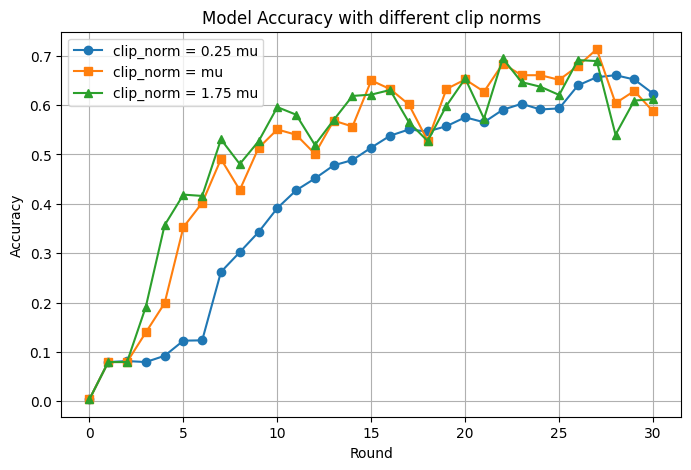

In [33]:
import matplotlib.pyplot as plt

rounds = list(range(0, 31))
accuracies = []
for h in history_list:
    acc = [a for _, a in h['metrics_centralized']['accuracy']]
    accuracies.append(acc)
    
plt.figure(figsize=(8, 5))
plt.plot(rounds, accuracies[0], label="clip_norm = 0.25 mu", marker="o")
plt.plot(rounds, accuracies[1], label="clip_norm = mu", marker="s")
plt.plot(rounds, accuracies[2], label="clip_norm = 1.75 mu", marker="^")

plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different clip norms")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

Since no noise is being added, the clipping norm is the only factor affecting the convergence speed. A lower norm gives more aggressive clipping, so the magnitude of updates are smaller, leading to slower convergence. Meanwhile, a high norm of gives faster convergence initially because of the larger updates, but it can lead to instability.

From the plot, we see that the clip norm of mu and 1.75mu converge much faster in the beginning. However, 1.75 is a bit more unstable. At the end, the clip norm of mu gives the highest accuracy, although only by a hair.

Note that when clipping by 1.75, most updates are not exceeding the clip, and thus just remain as they were (are not clipped).

**Question 4 (Part II ✅ | Part III/MPhil ✅):**

(You must provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

This question extends the one above to investigate the effect that the `clip_norm` has upon the norm of the federated model update. The federated model update is defined as the difference between the model at the start of the round and the model post-aggregation.

1. Using the results from the above question, plot the following:

   - The L2 norm of the federated model deltas across rounds for the three bounds above. How does L2 norm of the federated model delta compare to `clip_norm` (draw a horizontal line for all three bounds)? Is the behaviour as you expected, and why/why not?
   - The accuracy on the federated test set of models trained using the three norms above against the cumulative L2 norm accumulated across rounds as the axis. Consider the accuracy of the initial parameter test (round 0) to map to an L2 norm of 0. By cumulative L2, we mean a running sum where you keep adding the new norm value to the sum and then add the sum to a per-round list. Such a sum can easily be computed from a list using a `accumulate()` call.

2. How do the L2 norms of the federated model deltas compare against the change in accuracy between rounds? Is the relationship predictable and/or linear? Consider all the `clip_norm` values you have tried in your response and provide potential explanations for why/why not the relationship between accuracy and cumulative L2 changes between bounds.


In [ ]:
# i couldn't figure out how to save deltas in the metrics object, so i stored it in a variable. it's copied here for use when the notebook is restarted.
deltas = [[2.007906695499345, 6.635527364867281, 6.800695816418676], [1.8591531661296778, 4.949056795871353, 5.939356005806449], [2.040711651650112, 7.0160346390307735, 7.978855732654531], [1.7410558586388263, 7.5079515815945355, 9.126702288641772], [1.8600337935704376, 7.370792129906911, 8.513230613747323], [1.8989598276948183, 8.062096730751788, 9.308127800719848], [1.9675480526482652, 6.348452567010391, 7.6399070613987705], [2.095348818999107, 7.338543608066444, 8.913676197009705], [2.097548055746192, 6.484640705626669, 7.524037307519348], [2.042232250306247, 7.211670673619415, 8.46055085403979], [2.0125884562956573, 7.344766721693917, 8.219554853398243], [2.0305004252698806, 6.9527803660389855, 8.240940661198415], [2.0446976204256537, 6.646011966872995, 7.167912185172075], [2.028380159890986, 6.736192026926936, 7.808647653750192], [2.0657431195810334, 6.270098922573556, 7.01399204245737], [2.0163548702072482, 6.15282489653017, 6.972854064154291], [1.9793873609455075, 6.941263110587752, 8.255982232948096], [1.96639825173557, 6.703059950958129, 7.712736816583158], [1.971256481504483, 7.03241959541329, 7.694073786508682], [2.055941647264984, 6.497591267649789, 6.940885578173061], [1.9278449379511187, 6.378339461852678, 7.225373793895883], [2.0477496441035545, 5.962193636941294, 6.55028552607626], [1.9685047188077478, 6.256775702157071, 7.222021103544959], [1.984605422804736, 6.04527730139684, 6.71659975729873], [1.962392829432369, 6.399531722669886, 7.009349735341321], [1.9280836222118534, 5.9319191453976545, 6.550341376912633], [1.9026237700685957, 6.359199777589868, 6.588155419580275], [1.9372745689461357, 7.11113801219384, 8.203277894199037], [1.9466652158685809, 5.949436707468003, 6.451576980229617], [1.9816191987962368, 7.004175764764749, 7.274980140051385]]
clip_025_delta = [d[0] for d in deltas]
clip_1_delta = [d[1] for d in deltas]
clip_175_delta = [d[2] for d in deltas]

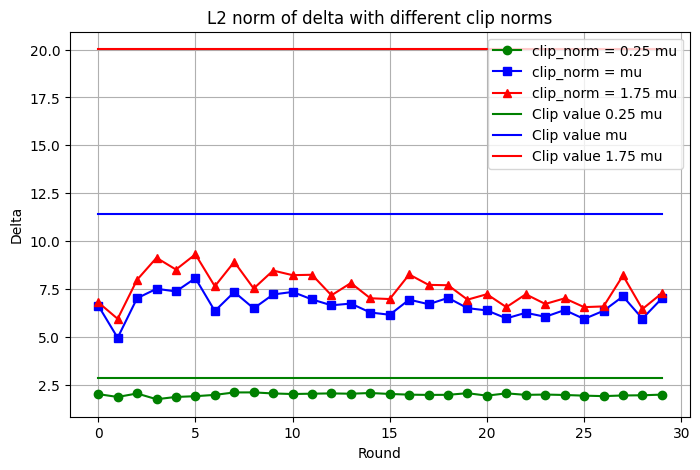

In [ ]:
rounds = list(range(len(clip_1_delta)))
plt.figure(figsize=(8, 5))
plt.plot(rounds, clip_025_delta, label="clip_norm = 0.25 mu", marker="o", color="g")
plt.plot(rounds, clip_1_delta, label="clip_norm = mu", marker="s", color="b")
plt.plot(rounds, clip_175_delta, label="clip_norm = 1.75 mu", marker="^", color="r")

line_025 = [0.25 * avg_norm] * len(clip_1_delta)
line_1 = [avg_norm] * len(clip_1_delta)
line_175 = [1.75 * avg_norm] * len(clip_1_delta)
plt.plot(rounds, line_025, label="Clip value 0.25 mu", marker="", color="g")
plt.plot(rounds, line_1, label="Clip value mu", marker="", color="b")
plt.plot(rounds, line_175, label="Clip value 1.75 mu", marker="", color="r")

plt.xlabel("Round")
plt.ylabel("Delta")
plt.title("L2 norm of delta with different clip norms")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
import itertools
clip025_accumulated = list(itertools.accumulate(clip_025_delta))
clip1_accumulated = list(itertools.accumulate(clip_1_delta))
clip175_accumulated = list(itertools.accumulate(clip_175_delta))

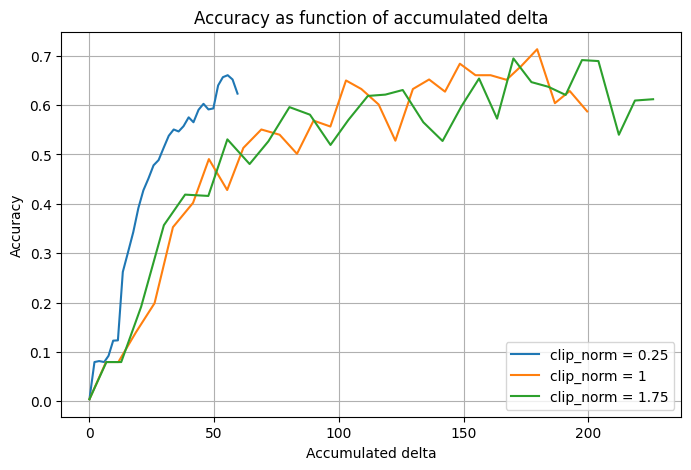

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot([0] + clip025_accumulated, accuracies[0], label="clip_norm = 0.25")
plt.plot([0] + clip1_accumulated, accuracies[1], label="clip_norm = 1")
plt.plot([0] + clip175_accumulated, accuracies[2], label="clip_norm = 1.75")

plt.xlabel("Accumulated delta")
plt.ylabel("Accuracy")
plt.title("Accuracy as function of accumulated delta")
plt.legend()
plt.grid(True)

plt.show()

1. We see that the L2 norm of the delta is always smaller than the clip used. This is expected, because norm is clipped, the delta should not be able to reach a numerical value that is larger than that clip. We also see that the higher clip of 1.75 has deltas slightly higher than the clip of 1, but the difference is not big.

2. We see that the smaller clip norm changes faster as a function of the delta, while the larger clip norm changes slower. The relationship is initially close to linear, but then flattens out as the accuracy of the model starts to converge. A way of analyzing this is that although the higher deltas (corresponding to higher clip values and thus faster convergence per round) give a faster convergence per round, the convergence is not faster as a function of the delta. This means that changing the parameters faster (higher delta) has a worse/slower convergence per change in parameters compared to changing the parameters slower (low delta). 


## 3.2 Adaptive Norm Bound DP


Having investigated the impact of gradient clipping with a fixed norm on performance, you may wonder if your chosen norm will stay appropriate for the entire training.

To avoid perfectly tuning a fixed `clip_norm` an [adaptive version of DPFedAvg](https://arxiv.org/abs/1905.03871) was proposed in paper \[3], which attempts to automatically scale the bound on the L2 norm of model updates based on a quantile of L2 norms provided by clients in a given round. As computing such a value would be computationally expensive and require clients to send private values, the paper proposes an algorithm meant to approximate the quantile.

Specifically, it adjusts the `clip_norm` parameter as:

>     self.clip_norm *= math.exp(-self.clip_norm_lr

            * (noised_clients_with_clipped_norm_fraction - self.clip_norm_target_quantile)
        )

where the new clip norm depends on a learning rate, the fraction of clients used in training who have clipped their norms (with added noise), and the target quantile. In the code below, the clients who have clipped their norm are reported via a set bit in the config, and thus `noised_clients_with_clipped_norm_fraction` is replaced with `noised_norm_bit_set_fraction`. By knowing approximately how many clients fall below a given norm, we can iteratively improve the `clip_norm` until the percentage of clients with norms smaller than the bound is reached.

The new implementation is hard to use and balance for short experiments such as ours as it includes an initial phase where the norm grows exponentially in its attempts to converge to the actual quantile. Given that we do not want any further interference making the behaviour of DP harder to predict, this would prove inconvenient when trying to deduce the impact of noise. As such, we shall only track the behaviour of the adaptive norm and use the predictable `DPFedAvgFixed` when experimenting with obtaining a given level of $\epsilon$ privacy.


In [ ]:
"""DP-FedAvg [Andrew et al., 2019] with adaptive clipping.
Paper: https://arxiv.org/pdf/1905.03871.pdf
"""

# Original implementation by Vasundhara Agarwal

deltas_adaptive = [[] for _ in range(100)]

class DPFedAvgAdaptive(DPFedAvgFixed):
    """Server-side adaptive clipping for DP-FedAvg."""

    # pylint: disable=too-many-arguments,too-many-instance-attributes
    def __init__(
        self,
        *,
        fraction_fit: float = 1.0,
        fraction_evaluate: float = 1.0,
        min_fit_clients: int = 2,
        min_evaluate_clients: int = 2,
        min_available_clients: int = 2,
        evaluate_fn: (
            Callable[
                [int, NDArrays, dict[str, Scalar]],
                tuple[float, dict[str, Scalar]] | None,
            ]
            | None
        ) = None,
        on_fit_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        on_evaluate_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        accept_failures: bool = False,
        initial_parameters: Parameters | None = None,
        fit_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        evaluate_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        server_learning_rate: float = 1.0,
        server_momentum: float = 0.0,
        num_clients_per_round: int,
        init_clip_norm: float = 0.1,
        noise_multiplier: float = 1,
        server_side_noising: bool = True,
        clip_norm_lr: float = 0.2,
        clip_norm_target_quantile: float = 0.5,
        clip_count_stddev: float | None = None,
    ) -> None:
        super().__init__(
            fraction_fit=fraction_fit,
            fraction_evaluate=fraction_evaluate,
            min_fit_clients=min_fit_clients,
            min_evaluate_clients=min_evaluate_clients,
            min_available_clients=min_available_clients,
            evaluate_fn=evaluate_fn,
            on_fit_config_fn=on_fit_config_fn,
            on_evaluate_config_fn=on_evaluate_config_fn,
            accept_failures=accept_failures,
            initial_parameters=initial_parameters,
            fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
            evaluate_metrics_aggregation_fn=evaluate_metrics_aggregation_fn,
            server_learning_rate=server_learning_rate,
            server_momentum=server_momentum,
            num_clients_per_round=num_clients_per_round,
            clip_norm=init_clip_norm,
            noise_multiplier=noise_multiplier,
            server_side_noising=server_side_noising,
        )
        self.clip_norm_lr = clip_norm_lr
        self.clip_norm_target_quantile = clip_norm_target_quantile
        self.clip_count_stddev = clip_count_stddev

        # Decides the level of noise added to the fraction of clients which have clipped
        # their norms
        if self.clip_count_stddev is None:
            self.clip_count_stddev = 0
            if noise_multiplier > 0:
                self.clip_count_stddev = self.num_clients_per_round / 20.0

        if noise_multiplier:
            self.noise_multiplier = (
                self.noise_multiplier ** (-2) - (2 * self.clip_count_stddev) ** (-2)
            ) ** (-0.5)

    def configure_fit(
        self, server_round: int, parameters: Parameters, client_manager: ClientManager
    ) -> list[tuple[ClientProxy, FitIns]]:
        """Configure the next round of training."""
        additional_config = {"dpfedavg_adaptive_clip_enabled": True}

        client_instructions = super().configure_fit(
            server_round, parameters, client_manager
        )

        for _, fit_ins in client_instructions:
            fit_ins.config.update(additional_config)

        return client_instructions

    def _update_clip_norm(self, results: list[tuple[ClientProxy, FitRes]]) -> None:
        """Update the clipping norm based on the fraction of clients which clipped."""
        # Calculating number of clients which set the norm indicator bit
        norm_bit_set_count = 0
        for client_proxy, fit_res in results:
            if "dpfedavg_norm_bit" not in fit_res.metrics:
                raise DPClientNormBitError(
                    f"Indicator bit not returned by client with id {client_proxy.cid}."
                )

            if fit_res.metrics["dpfedavg_norm_bit"]:
                norm_bit_set_count += 1
        # Noising the count
        noised_norm_bit_set_count = float(
            np.random.normal(norm_bit_set_count, self.clip_count_stddev)
        )

        noised_norm_bit_set_fraction = noised_norm_bit_set_count / len(results)
        # Geometric update
        self.clip_norm *= math.exp(
            -self.clip_norm_lr
            * (noised_norm_bit_set_fraction - self.clip_norm_target_quantile)
        )

    def aggregate_fit(
        self,
        server_round: int,
        results: list[tuple[ClientProxy, FitRes]],
        failures: list[tuple[ClientProxy, FitRes] | BaseException],
    ) -> tuple[Parameters | None, dict[str, Scalar]]:
        """Aggregate the results of the training round."""
        if not self.accept_failures and failures:
            return None, {}

        new_global_model, metrics = super().aggregate_fit(
            server_round, results, failures
        )
        self._update_clip_norm(results)
        metrics["adaptive_clip_norm"] = self.clip_norm

        return new_global_model, metrics

In [65]:
# New function to run the adaptive norm experiments with sensible defaults

dp_client_generator = get_dp_client_generator(
    network_generator_cnn,
    data_dir,
    federated_partition,
    lambda x: client_samples_dataframe.cid[x],
)


adaptive_default_parameters: dict = {
    "train_config": get_default_train_config(),
    "test_config": get_default_test_config(),
    "num_total_clients": num_total_clients,
    "num_clients_per_round": 4,
    "num_evaluate_clients": 0,
    "num_evaluate": 0,
    "accept_failures": False,
    "min_fit_clients": 2,
    "min_available_clients": 2,
    "initial_parameters": ndarrays_to_parameters(seed_model_cnn_params),
    "client_generator": dp_client_generator,
    "seed": Seeds.DEFAULT,
    "num_rounds": 30,
    "strategy": DPFedAvgAdaptive,
    "fed_eval": True,
    "server_side_noising": True,
    "clip_count_stddev": None,
}


def run_dp_adaptive_fl(
    noise_multiplier: float = 0,
    init_clip_norm: float = 2,
    clip_norm_lr: float = 0.2,
    clip_norm_target_quantile: float = 0.5,
    default_parameters: dict = adaptive_default_parameters,
    **kwargs: dict[str, Any],
) -> Any:
    """Execute a DP-FedAvg simulation with adaptive clipping."""
    parameters: dict = {**default_parameters, **kwargs}

    def on_fit_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["train_config"]

    def on_evaluate_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["test_config"]

    fraction_fit: float = (
        float(parameters["num_clients_per_round"]) / parameters["num_total_clients"]
    )
    fraction_evaluate: float = (
        float(parameters["num_evaluate_clients"]) / parameters["num_total_clients"]
    )

    strategy = parameters["strategy"](
        num_clients_per_round=parameters["num_clients_per_round"],
        fraction_fit=fraction_fit,
        fraction_evaluate=fraction_evaluate,
        min_fit_clients=parameters["min_fit_clients"],
        min_available_clients=parameters["min_available_clients"],
        on_fit_config_fn=on_fit_config_fn,
        on_evaluate_config_fn=on_evaluate_config_fn,
        initial_parameters=parameters["initial_parameters"],
        accept_failures=parameters["accept_failures"],
        evaluate_fn=(
            federated_evaluation_function if parameters["fed_eval"] is True else None
        ),
        fit_metrics_aggregation_fn=aggregate_weighted_average,
        evaluate_metrics_aggregation_fn=aggregate_weighted_average,
        init_clip_norm=init_clip_norm,
        clip_norm_lr=clip_norm_lr,
        clip_norm_target_quantile=clip_norm_target_quantile,
        noise_multiplier=noise_multiplier,
        server_side_noising=parameters["server_side_noising"],
        clip_count_stddev=parameters["clip_count_stddev"],
    )
    client_manager = CustomClientManager(criterion=None, seed=parameters["seed"])
    server = Server(
        client_manager=client_manager,
        strategy=strategy,
    )
    return start_seeded_simulation(
        client_fn=lambda cid: parameters["client_generator"](cid).to_client(),
        num_clients=parameters["num_total_clients"],
        server=server,
        config=ServerConfig(num_rounds=parameters["num_rounds"]),
        strategy=strategy,
        seed=parameters["seed"],
        name=f"adaptive_target_{clip_norm_target_quantile}_init_clip_norm_{init_clip_norm}_lr_{clip_norm_lr}_noise_{noise_multiplier}",
    )

In [40]:
parameters_for_every_round, hist_adaptive_quantile_0_5 = run_dp_adaptive_fl(
    clip_norm_target_quantile=0.5, noise_multiplier=0
)

100%|██████████| 47/47 [00:00<00:00, 181.12it/s]
ERROR flwr 2025-02-24 23:31:30,339 | app.py:189 | list index out of range
ERROR flwr 2025-02-24 23:31:30,341 | app.py:190 | Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/fl/lib/python3.10/site-packages/flwr/simulation/app.py", line 184, in start_simulation_no_ray
    parameters_list, hist = run_fl_return_parameters(
  File "/opt/homebrew/anaconda3/envs/fl/lib/python3.10/site-packages/flwr/server/app.py", line 249, in run_fl_return_parameters
    parameters_list, hist = server.fit(num_rounds=config.num_rounds, timeout=config.round_timeout)
  File "/opt/homebrew/anaconda3/envs/fl/lib/python3.10/site-packages/flwr/server/server_returns_parameters.py", line 102, in fit
    res_fit = self.fit_round(
  File "/opt/homebrew/anaconda3/envs/fl/lib/python3.10/site-packages/flwr/server/server_returns_parameters.py", line 249, in fit_round
    ] = self.strategy.aggregate_fit(server_round, results, failures)
  File "/var/fold

RuntimeError: Simulation crashed.

Having gone through this slight detour to understand how we could obtain an adaptive bound which leaves the privacy budget mostly undisturbed without experimentation, we shall return to DP's primary goal, matching a given theoretical bound on privacy. However, Part III and MPhil students will now get to play around and observe the behaviour of this adaptive norm algorithm.


**Question 5 (Part III/MPhil ✅):**

(You need to provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

You will now examine the accuracy of adaptive norm clipping compared to the previously fixed norm clipping.

1. Using values of `clip_norm_target_quantile`$\in \{0.125,\, 0.5, \,0.875\}$ (you should already have results for the default value from the cells above. If you have lost it, look into the `histories` folder). Run `DPFedAvgAdaptive` experiments with the same parameters as the above example using a `noise_multiplier=0`.
2. Plot the per-round accuracy on the federated test set of models trained using the three quantile targets above. Which quantile target converges the fastest and to the highest final accuracy, and why do you think that is? Are the results as conclusive as the fixed bound ones? **Hint**: consider the exponential nature of the bound adaptation.
3. Do an ordered pairwise comparison between the plots of per-round accuracy of the previous three `clip_norm` results for the fixed norm experiments against the adaptive norm experiments, i.e., plot `clip_norm=mean*0.25` against `clip_norm_target_quantile=0.125`, `clip_norm=mean` against `clip_norm_target_quantile=0.5`, and `clip_norm=mean*1.75` against `clip_norm_target_quantile=0.875`. How does each of the pairs compare? Where are the differences most pronounced, and why do you think that is?


In [66]:
parameters_for_every_round, hist_adaptive_quantile_0_125 = run_dp_adaptive_fl(
    clip_norm_target_quantile=0.125, noise_multiplier=0
)
parameters_for_every_round, hist_adaptive_quantile_0_5 = run_dp_adaptive_fl(
    clip_norm_target_quantile=0.5, noise_multiplier=0
)
parameters_for_every_round, hist_adaptive_quantile_0_875 = run_dp_adaptive_fl(
    clip_norm_target_quantile=0.875, noise_multiplier=0
)

100%|██████████| 47/47 [00:00<00:00, 151.60it/s]


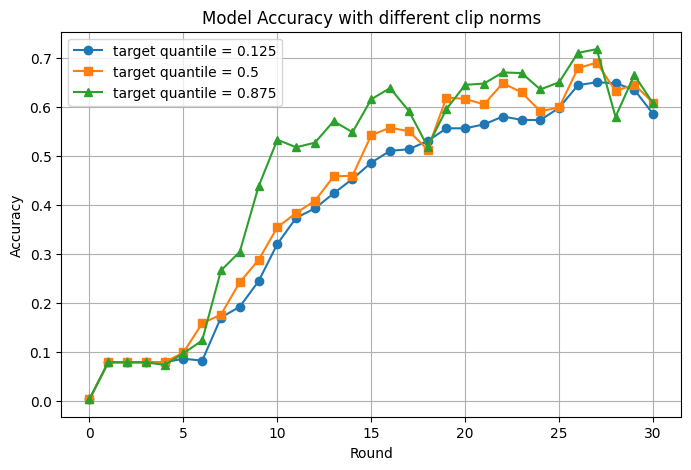

In [ ]:
import json
import matplotlib.pyplot as plt
history_list = []
with open('histories/hist_1740436551_adaptive_target_0.125_init_clip_norm_2_lr_0.2_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

with open('histories/hist_1740436788_adaptive_target_0.5_init_clip_norm_2_lr_0.2_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

with open('histories/hist_1740436866_adaptive_target_0.875_init_clip_norm_2_lr_0.2_noise_0.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

adaptive_accuracies = []
for h in history_list:
    acc = [a for _, a in h['metrics_centralized']['accuracy']]
    adaptive_accuracies.append(acc)

rounds = list(range(len(adaptive_accuracies[0])))
    
plt.figure(figsize=(8, 5))
plt.plot(rounds, adaptive_accuracies[0], label="target quantile = 0.125", marker="o")
plt.plot(rounds, adaptive_accuracies[1], label="target quantile = 0.5", marker="s")
plt.plot(rounds, adaptive_accuracies[2], label="target quantile = 0.875", marker="^")

plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different clip norms")
plt.legend()
plt.grid(True)

plt.show()

This exponential nature means that the clip_norm initially grows very quickly, but the rate of growth slows down over time as the algorithm attempts to converge toward the target quantile. Initially, it aggressively adjusts the clip norm, but as it stabilizes, the adjustments become much more gradual. When the adaptive method starts, the clip_norm will initially be far from the target quantile (especially for high quantiles like 0.875). Therefore, the clip norm will grow exponentially until it reaches a point where the fraction of clipped clients aligns with the target quantile.

We see that the higher target quantile of 0.875 initially grows a lot faster, but the difference between the norms is much lsess pronounced than when we used a fixed clip norm. This is because the adaptive clip norm algorithm smoothens the growth of the norm over time due to its exponential nature. Even though it starts with a rapid increase, it eventually stabilizes as it converges towards the target quantile. This behavior results in a smoother progression toward the optimal model, preventing overfitting from excessively large updates as seen with the higher fixed clip norms (like 7).

The difference between the quantiles (0.125, 0.5, and 0.875) is more pronounced in the early stages of training, as the clip_norm grows quickly. However, once the clip_norm has stabilized, the difference in performance between the target quantiles diminishes because the updates are all relatively small and the model is in a more stable state.

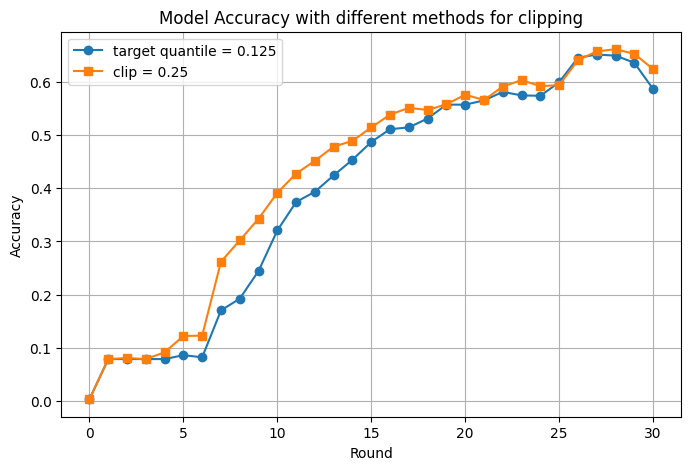

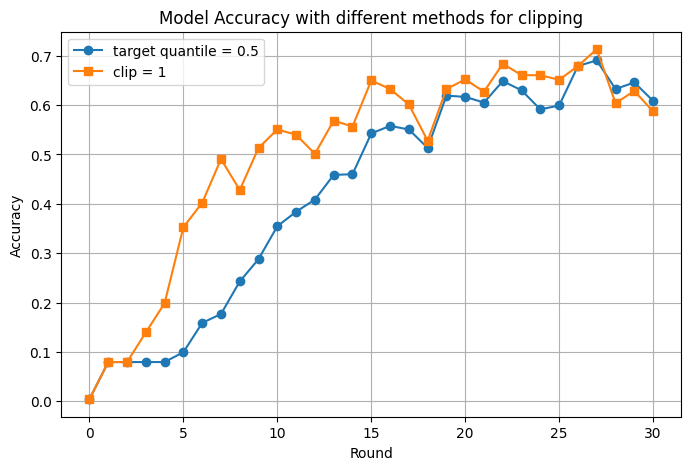

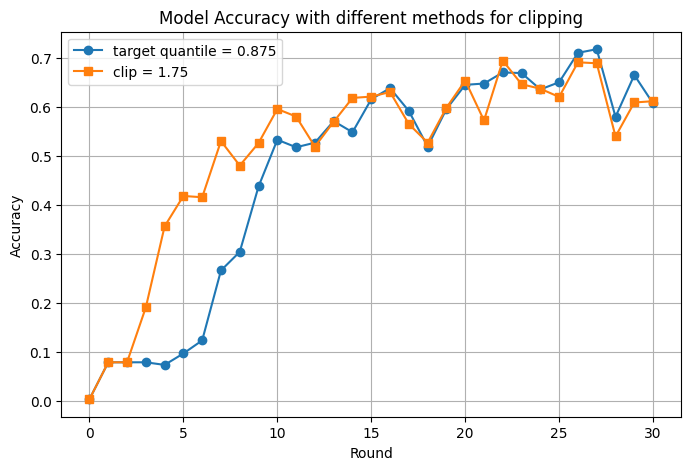

In [ ]:
plt.figure(figsize=(8, 5))
rounds = range(len(adaptive_accuracies[0]))
plt.plot(rounds, adaptive_accuracies[0], label="target quantile = 0.125", marker="o")
plt.plot(rounds, accuracies[0], label="clip = 0.25", marker="s")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different methods for clipping")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))
rounds = range(len(adaptive_accuracies[0]))
plt.plot(rounds, adaptive_accuracies[1], label="target quantile = 0.5", marker="o")
plt.plot(rounds, accuracies[1], label="clip = 1", marker="s")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different methods for clipping")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))
rounds = range(len(adaptive_accuracies[0]))
plt.plot(rounds, adaptive_accuracies[2], label="target quantile = 0.875", marker="o")
plt.plot(rounds, accuracies[2], label="clip = 1.75", marker="s")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different methods for clipping")
plt.legend()
plt.grid(True)

plt.show()

The similarities and differences between the fixed clip norm and adaptive norm experiments can be explained by how the adaptive norm evolves over time and how clipping affects model updates at different levels of the L2 norm.

We see that the differences are very small for the lowest clip value. At low clip norms, nearly all client updates are clipped, meaning the exact value of the clip norm matters less because updates are being uniformly scaled down.

There is a larger distance between the middle pair. This is because the adaptive norm takes time to adjust, starting lower and then gradually increasing as it learns a better bound. Meanwhile,  the fixed norm immediately uses the correct value throughout training. The difference is bigger in the early rounds, where the addaptive approach clips more aggresively. Over time, the adaptive norm then catches up as it finds the suitable clip value.

With high clip norms, clipping occurs much less frequently, meaning updates retain most of their original magnitudes. Here, the adaptive norm increases exponentially in the beginning until it reaches the target quantile. This can be seen in the plot, where we see that the adaptive norm reaches a similar accuracy to the fixed norm around round 10 (fast), whereas the slower adjusting clip of the middle case reaches it slightly slower (around round 15).


**Question 6 (Part III/MPhil ✅):**

(You need to provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

This is an extension to the previous question, which tries to expand upon how the adaptive norm applied to client gradients/updates affects the L2 norm of the federated model delta.

1. Using the previous results for `clip_norm_target_quantile`$\in \{0.125,\, 0.5, \,0.875\}$, plot the L2 norm of the federated model delta for each target quantile. Which of the target quantiles causes the most considerable oscillations in the federated L2 norm, and why do you think that is?
2. Do a similar ordered pairwise comparison between the federated L2 norm results of the target quantile experiments against those of the fixed bound experiments as in the previous question. Where is the gap between the adaptive and fixed method the largest?
3. Plot the accuracy of experiments with the adaptive bounds against the cumulative L2 norm.


In [70]:
deltas_adaptive = [[1.4052366032690535, 1.4537099109054235, 1.3689734553306248], [1.3765879009455704, 1.517141539439381, 1.5849919306129119], [1.5139705196283775, 1.753200434836377, 2.0192380191732044], [1.3639096402102053, 1.6915787757801575, 2.121739091958412], [1.440474436921092, 1.9506244518839386, 2.7216905602837613], [1.4799941679347175, 2.192474371434703, 3.1703425907062517], [1.5582735321198233, 2.5527974396973465, 4.064306988063845], [1.6984342166154895, 2.8914273651611095, 4.8745085200946034], [1.7825054899470196, 3.1989524943482883, 5.888856631975771], [1.83284042698327, 3.5408448009061453, 6.822406114971208], [1.8089990864270562, 3.8354373671263082, 7.853289245738996], [1.859084702882605, 4.254121358190273, 8.58418295536708], [1.9411166883489448, 4.755303759023204, 8.666496322901825], [2.0435912814363393, 5.372378675313747, 8.89175639404184], [2.0700845357365, 5.8058555562998055, 7.612968243530983], [2.0747595320473335, 6.310260584718868, 8.012937376130475], [2.0900741774826748, 6.994574690180123, 8.580228369580468], [2.1172416419990685, 6.898509661378644, 8.03889487999081], [2.1580959523170535, 8.03848032089612, 8.323198969725873], [2.316599936241985, 8.11811125800818, 7.508047971864025], [2.2485851028817794, 7.745403856248488, 7.629404774139142], [2.4342885237696716, 7.361332591926694, 7.160173032437693], [2.399098074251484, 7.034534393600779, 7.456860017937232], [2.5119283857255517, 7.235659443210559, 7.3781462170367345], [2.5201270281564594, 7.180670758966902, 7.54772975712195], [2.5733221429158815, 7.526684700764894, 6.999497205825906], [2.6258800486922853, 7.423203247975787, 7.389938431997795], [2.6983917807014874, 7.3953977489271, 8.137257150984869], [2.751471201220554, 7.154254993820922, 7.390258347600804], [2.8597923224648394, 7.441292676500402, 8.383062774239987]]
clip_125_delta = [d[0] for d in deltas_adaptive]
clip_05_delta = [d[1] for d in deltas_adaptive]
clip_875_delta = [d[2] for d in deltas_adaptive]

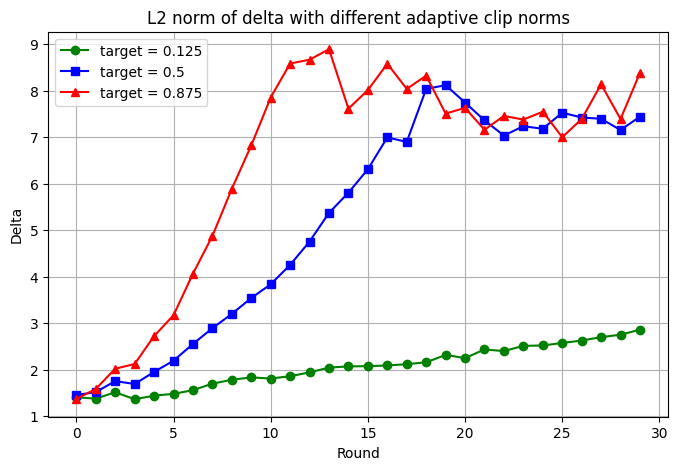

In [ ]:
rounds = list(range(len(clip_1_delta)))
plt.figure(figsize=(8, 5))
plt.plot(rounds, clip_125_delta, label="target = 0.125", marker="o", color="g")
plt.plot(rounds, clip_05_delta, label="target = 0.5", marker="s", color="b")
plt.plot(rounds, clip_875_delta, label="target = 0.875", marker="^", color="r")

plt.xlabel("Round")
plt.ylabel("Delta")
plt.title("L2 norm of delta with different adaptive clip norms")
plt.legend()
plt.grid(True)

plt.show()

1. We see that the deltas for the highest target quantile oscillate the most.  
A high target quantile means the clip norm is adjusted to be large enough to accommodate most client updates without clipping. As a result, most updates remain unclipped, leading to high variance in the updates received by the server. This variance manifests as oscillations in the per-round delta.

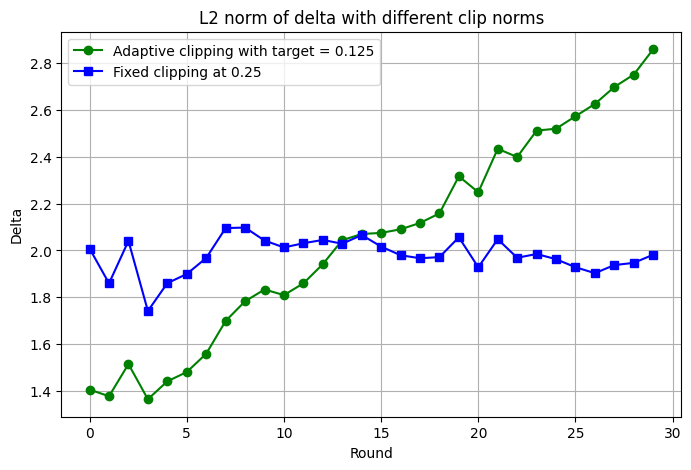

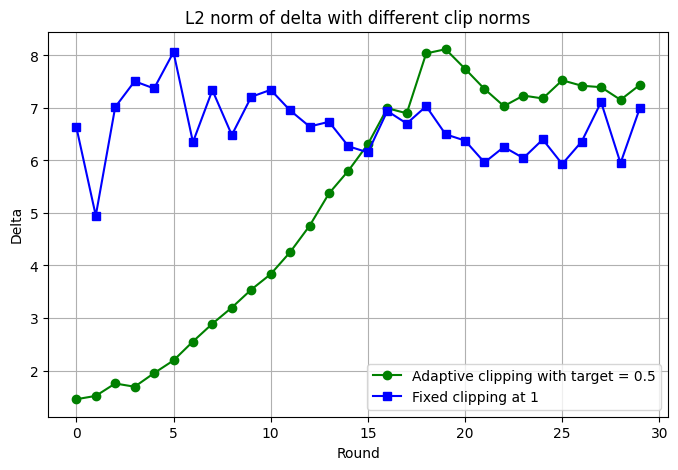

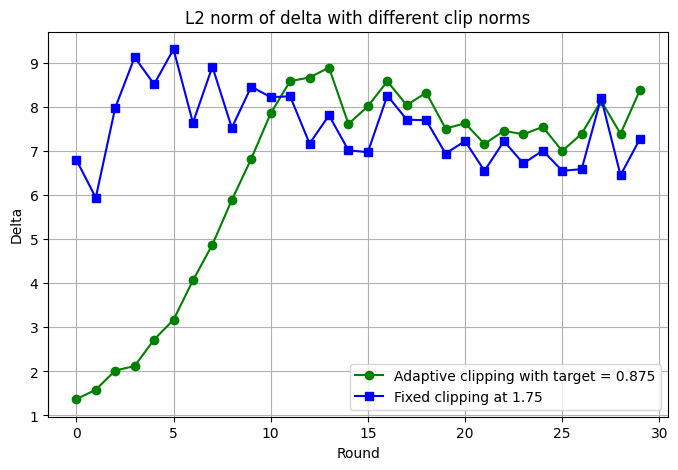

In [75]:
rounds = list(range(len(clip_1_delta)))
plt.figure(figsize=(8, 5))
plt.plot(rounds, clip_125_delta, label="Adaptive clipping with target = 0.125", marker="o", color="g")
plt.plot(rounds, clip_025_delta, label="Fixed clipping at 0.25", marker="s", color="b")

plt.xlabel("Round")
plt.ylabel("Delta")
plt.title("L2 norm of delta with different clip norms")
plt.legend()
plt.grid(True)

plt.show()

rounds = list(range(len(clip_1_delta)))
plt.figure(figsize=(8, 5))
plt.plot(rounds, clip_05_delta, label="Adaptive clipping with target = 0.5", marker="o", color="g")
plt.plot(rounds, clip_1_delta, label="Fixed clipping at 1", marker="s", color="b")

plt.xlabel("Round")
plt.ylabel("Delta")
plt.title("L2 norm of delta with different clip norms")
plt.legend()
plt.grid(True)

plt.show()

rounds = list(range(len(clip_1_delta)))
plt.figure(figsize=(8, 5))
plt.plot(rounds, clip_875_delta, label="Adaptive clipping with target = 0.875", marker="o", color="g")
plt.plot(rounds, clip_175_delta, label="Fixed clipping at 1.75", marker="s", color="b")

plt.xlabel("Round")
plt.ylabel("Delta")
plt.title("L2 norm of delta with different clip norms")
plt.legend()
plt.grid(True)

plt.show()

2. All of the comparisons are very different at the start, since the adaptive approach needs to adjust its clipping while the fixed approach has its target clipping at the beginning. Towards the end, the biggest difference is found between the comparison with the lowest clipping (0.25 mu and 0.125 target). This is because the fixed clipping forces the deltas to remain low, while the adaptive one allows for ramping up the clipping when it is safe to do so, allowing for bigger updates (bigger deltas).

In [76]:
import itertools
clip125_accumulated = list(itertools.accumulate(clip_125_delta))
clip05_accumulated = list(itertools.accumulate(clip_05_delta))
clip875_accumulated = list(itertools.accumulate(clip_875_delta))

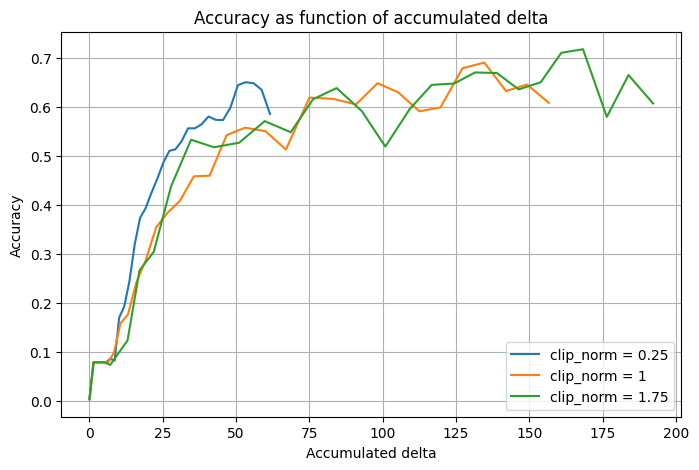

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot([0] + clip125_accumulated, adaptive_accuracies[0], label="clip_norm = 0.25")
plt.plot([0] + clip05_accumulated, adaptive_accuracies[1], label="clip_norm = 1")
plt.plot([0] + clip875_accumulated, adaptive_accuracies[2], label="clip_norm = 1.75")

plt.xlabel("Accumulated delta")
plt.ylabel("Accuracy")
plt.title("Accuracy as function of accumulated delta")
plt.legend()
plt.grid(True)

plt.show()

# 4 Epsilon-delta Privacy


We are now ready to understand the full extent of the DPFedAvg fixed algorithm and the relation between its privacy guarantees and the accuracy of the final model.

Before this, we should establish what a particular set of DP parameters implies for the level of privacy theoretically. The function below shall allow us to do just that while assuming a fixed number of rounds and clients per round. It adapts a function provided by TensorFlow privacy for DP-SGD, as we have established that DP-FedAvg and DP-SGD are equivalent when considering a mere reframing of samples as clients; it should provide sufficient accuracy for our purposes.


In [93]:
from tensorflow_privacy.privacy.analysis.compute_dp_sgd_privacy_lib import (
    compute_dp_sgd_privacy,
)
from contextlib import redirect_stdout
from io import StringIO


class NullIO(StringIO):
    """Custom IO interface to cut-out annoying messages."""

    def write(self, txt: str) -> None:
        """Implement custom empty write function."""
        # This function intentionally does nothing


def compute_fl_privacy(
    num_rounds: int = 25,
    noise_multiplier: float = 1.0,
    num_total_clients: int = num_total_clients,
    num_fit_clients: int = 4,
) -> float:
    """Compute the privacy bound `epsilon`."""
    with redirect_stdout(NullIO()):
        vals = compute_dp_sgd_privacy(
            n=num_total_clients,
            batch_size=num_fit_clients,
            noise_multiplier=noise_multiplier,
            epochs=num_rounds,
            delta=num_total_clients ** (-1),
        )
    return vals[0]

In [94]:
log(INFO, compute_fl_privacy(noise_multiplier=0.05))
log(INFO, compute_fl_privacy(noise_multiplier=1.0))

**Question 7 (Part II ✅ | Part III/MPhil ✅):**

(While this is a largely conceptual question, it does require you to provide a small amount of **code** and several **plots**. Answers to the purely conceptual components should contain **no more than 5 sentences**.)

Using the function mentioned above, study the impact of different parameters on the privacy guarantees of DP-FedAvg as follows:

1. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary the noise multiplier from 0.05 to 2 using an increment of 0.05. Use the noise multiplier as the x-axis.

2. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary `num_rounds` between $2^0$ and $2^{15}$ increasing using all the powers of two in the interval. Use the `num_rounds` as the x-axis.

3. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary `num_fit_cliets` from $2^0$ to $2^{10}$ increasing using all the powers of two in the interval. Use the `num_fit_cliets` as x-axis.

4. Describe the trade-offs you see and how they relate to FL privacy. <!-- Then, given the lecture by Peter Kairouz, what do you think the implications of these trade-offs are upon the practicality of Differential Privacy in FL? --> Then, what do you think are the implications of these trade-offs upon the practicality of differential privacy in FL?


In [135]:
epsilon_values_1 = []
for i in range(20):
    multiplier = 0.05 + 0.05 * i
    eps = compute_fl_privacy(noise_multiplier=multiplier)
    epsilon_values_1.append(eps)

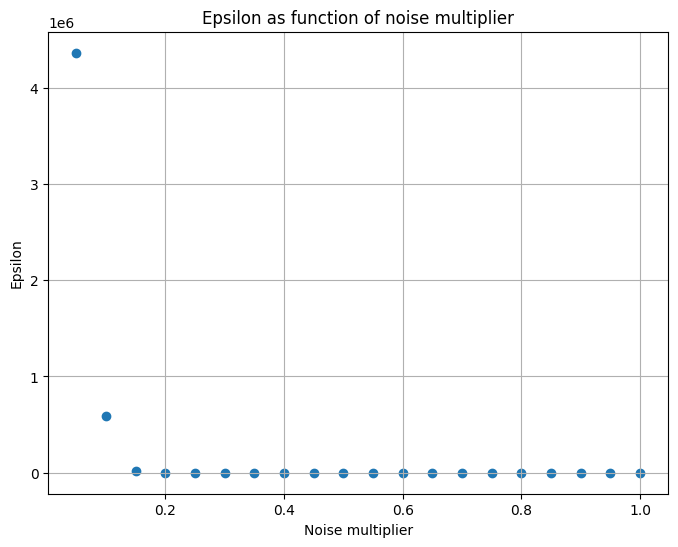

In [136]:
plt.figure(figsize=(8,6))
multipliers = [0.05 + 0.05 * i for i in range(20)]
plt.scatter(multipliers, epsilon_values_1)
plt.xlabel("Noise multiplier")
plt.ylabel("Epsilon")
plt.title("Epsilon as function of noise multiplier")
plt.grid(True)
plt.show()

In [137]:
epsilon_values_2 = []
for i in range(16):
    num_rounds = 2 ** i
    eps = compute_fl_privacy(num_rounds=num_rounds)
    epsilon_values_2.append(eps)

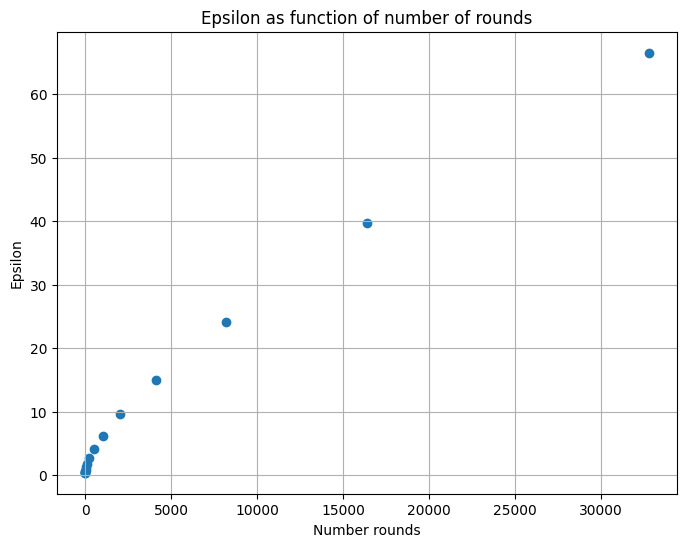

In [138]:
plt.figure(figsize=(8,6))
num_rounds = [2 ** i for i in range(16)]
plt.scatter(num_rounds, epsilon_values_2)
plt.xlabel("Number rounds")
plt.ylabel("Epsilon")
plt.title("Epsilon as function of number of rounds")
plt.grid(True)
plt.show()

In [139]:
epsilon_values_3 = []
for i in range(11):
    num_clients = 2 ** i
    eps = compute_fl_privacy(num_fit_clients=num_clients)
    epsilon_values_3.append(eps)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


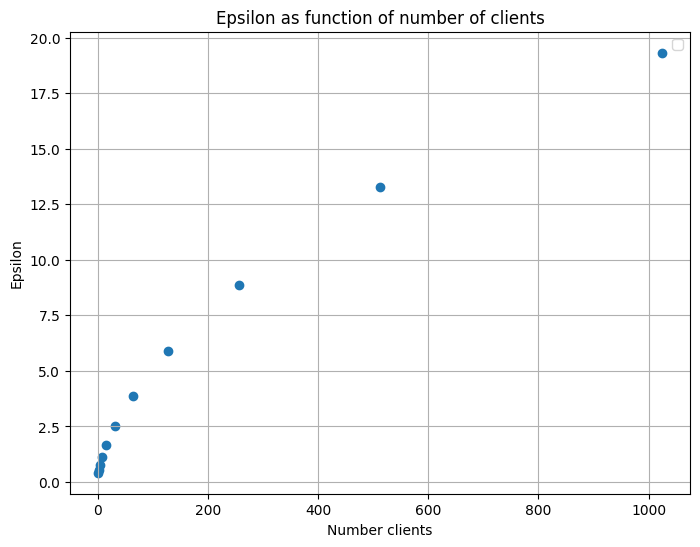

In [140]:
plt.figure(figsize=(8,6))
num_clients = [2 ** i for i in range(11)]
plt.scatter(num_clients, epsilon_values_3)
plt.xlabel("Number clients")
plt.ylabel("Epsilon")
plt.title("Epsilon as function of number of clients")
plt.legend()
plt.grid(True)
plt.show()

We see that the noise multiplier greatly decreases epsilon, leading to better privacy. Meanwhile, the number of clietns and number of rounds growing leads to a higher epsilon, meaning worse privacy. This shows that in settings where we train for many rounds or have a high number of clients, we need to use a higher noise multiplier to maintain privacy. This, in turn, will affect accuracy, suggesting that DP in FL is not ideal for very high numbers of clients or training rounds.

Armed with this theoretical understanding of the privacy budget, we can explore the performance implications of Differential Privacy upon DPFedAvgFixed. Note once more that the experiments we are running are small scale, as such you may find particularly high sensitivity to the `noise_multiplier` to be present.


**Question 8 (Part II ✅ | Part III/MPhil ✅):**

(You need to provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

Using the results of the previous experiment, observe the impact that a given noise multiplier has on both performance and privacy when using a **fixed** norm bound.

1. Set a `noise_multiplier`$\in \{0.1\}$ while keeping all other parameters constant. Then run the FL simulation using the `DPFedAvgFixed` strategy from above.

2. Plot accuracy and compare the convergence curves against the results you have for the previous experiment with a multiplier of $0.05$ (`hist_clip_bound_4_noise_0_05`). _NOTE: it was done just after defining the aforementioned strategy._

3. Use the `compute_fl_privacy` function to compute the epsilon value of two noise levels mentioned above. How does the epsilon of a given noise level relate to the accuracy achieved by that model? Does the relationship between the two fit your expectations from the question above?


In [141]:
parameters_for_every_round, hist_clip_bound_4_noise_0_5 = run_dp_fixed_fl(4, noise_multiplier=0.5)

100%|██████████| 47/47 [00:00<00:00, 162.33it/s]


In [142]:
history_list = []
with open('histories/hist_1740429575_fixed_clip_norm_4_noise_0.05.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

with open('histories/hist_1740447069_fixed_clip_norm_4_noise_0.5.json', 'r') as file:
    data = dict(json.load(file))
    history_list.append(data)

dp_accuracies = []
for h in history_list:
    acc = [a for _, a in h['metrics_centralized']['accuracy']]
    dp_accuracies.append(acc)

rounds = range(len(dp_accuracies[0]))

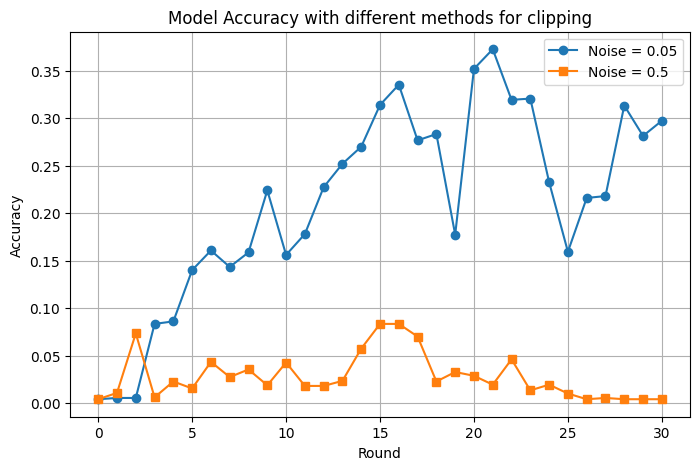

In [143]:
plt.figure(figsize=(8, 5))
plt.plot(rounds, dp_accuracies[0], label="Noise = 0.05", marker="o")
plt.plot(rounds, dp_accuracies[1], label="Noise = 0.5", marker="s")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Model Accuracy with different methods for clipping")
plt.legend()
plt.grid(True)

plt.show()

In [145]:
print(f"Epsilon for noise=0.05: {compute_fl_privacy(num_rounds=20, num_fit_clients=4, num_total_clients=num_total_clients, noise_multiplier=0.05)}")
print(f"Epsilon for noise=0.5: {compute_fl_privacy(num_rounds=20, num_fit_clients=4, num_total_clients=num_total_clients, noise_multiplier=0.5)}")

Epsilon for noise=0.05: 3490647.8618542617
Epsilon for noise=0.5: 6.4118554535779335


We see that noise=0.5 results in a model that is not learning at all. Meanwhile, this model has a much better epsilon value of 6.4 compared to 3490647. There is clearly a relationship that higher epsilon values lead to better accuracy and vice versa. This is as would be expected: we would expect that more noise makes updates more private, but cause issues with convergence. This was also seen in the previous question, where increasing noise greatly decreased the epsilon values.

# End of Part I

Continue to part 2.


(c) 2024 Alexandru-Andrei Iacob, Lorenzo Sani
